# Kitchen & Living Room Air Quality Analysis

**Background**

After the bathroom sensor, I wanted to understand air quality in the rest of the home — specifically whether cooking events could be detected from sensor data, and whether kitchen activity affects the living room.

Setup:
- **Kitchen**: GP2Y dust sensor + DHT22 temperature/humidity on an ESP32
- **Living room**: BME680 (temperature, humidity, pressure, gas resistance)

Alongside the sensor data, I manually logged every cooking event, window open/close, and appliance use over 3 days. Without that event log, the sensor readings are just numbers.

Dataset: 945 kitchen rows, 9,333 living room rows, 22 labelled events.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('images', exist_ok=True)

plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1d27'
plt.rcParams['text.color'] = '#e8e8f0'
plt.rcParams['axes.labelcolor'] = '#888899'
plt.rcParams['xtick.color'] = '#888899'
plt.rcParams['ytick.color'] = '#888899'

## 1. Load and clean kitchen data

The kitchen sensor exports Korean-formatted timestamps and has no header row. The first rows contain `-1` temperature values — the sensor warming up. Those are dropped.

The dust sensor (GP2Y) outputs raw ADC values (0–1023). Zero readings are a timing artefact where the LED pulse and ADC read misalign — also dropped.

In [31]:
def parse_korean_dt(s):
    try:
        s = str(s).replace('\uc624\uc804', 'AM').replace('\uc624\ud6c4', 'PM').replace('. ', '/')
        s = s.replace('/', '-', 2)
        return pd.to_datetime(s, format='%Y-%m-%d %p %I:%M:%S')
    except:
        return pd.NaT

kt = pd.read_csv('data/kitchen_data.csv', header=None, skiprows=1)
kt.columns = ['timestamp', 'temperature', 'humidity', 'dust_raw', 'location', 'c5', 'c6', 'c7', 'c8']
kt = kt[['timestamp', 'temperature', 'humidity', 'dust_raw']].copy()
kt = kt[kt['timestamp'].notna() & (kt['timestamp'] != '')]
kt['ts'] = kt['timestamp'].apply(parse_korean_dt)
kt = kt[kt['ts'].notna()].copy()
for col in ['temperature', 'humidity', 'dust_raw']:
    kt[col] = pd.to_numeric(kt[col], errors='coerce')
kt = kt[(kt['temperature'] > 0) & (kt['dust_raw'] > 0)].sort_values('ts').reset_index(drop=True)

# ADC to ug/m3 (GP2Y1010AU0F datasheet formula)
kt['voltage'] = kt['dust_raw'] * (5.0 / 1024.0)
kt['dust_ugm3'] = ((kt['voltage'] - 0.9) / 0.005).clip(lower=0)

print(f"Kitchen: {len(kt)} rows after cleaning")
print(f"Time range: {kt['ts'].min()} -> {kt['ts'].max()}")
print(f"Dust: {kt['dust_ugm3'].min():.0f} - {kt['dust_ugm3'].max():.0f} ug/m3, mean {kt['dust_ugm3'].mean():.0f}")

Kitchen: 875 rows after cleaning
Time range: 2026-04-09 19:43:19 -> 2026-04-12 18:12:13
Dust: 0 - 378 ug/m3, mean 68


## 2. Load living room data

In [34]:
lr = pd.read_csv('data/livingroom.csv')
lr['ts'] = lr['Timestamp'].apply(parse_korean_dt)
lr = lr[lr['ts'].notna()].sort_values('ts').reset_index(drop=True)
for col in ['Temperature', 'Humidity', 'Gas', 'Pressure']:
    lr[col] = pd.to_numeric(lr[col], errors='coerce')

print(f"Living room: {len(lr)} rows")
print(f"Time range: {lr['ts'].min()} -> {lr['ts'].max()}")
print(lr[['Temperature', 'Humidity', 'Gas']].describe().round(2))

Living room: 9333 rows
Time range: 2026-04-12 11:14:28 -> 2026-04-12 18:12:49
       Temperature  Humidity      Gas
count      9333.00   9333.00  9333.00
mean         24.75     41.53   122.34
std           2.70      2.37    17.89
min          18.73      3.00    39.43
25%          22.68     39.86   114.96
50%          25.78     41.88   118.21
75%          26.82     43.10   123.62
max          29.93     61.40   992.98


## 3. Load the event log

Every cooking session, window open/close, and appliance use was recorded manually in real time on a phone. This is the ground truth that connects sensor readings to real-world activity.

Timestamps may have small offsets (1–2 minutes). `kitchen fan on`, `microwave on`, and `airfryer on` were logged separately to see if different cooking methods have different dust signatures.

In [35]:
events = [
    ('2026-04-09 20:46', '2026-04-09 21:18', 'cooking'),
    ('2026-04-09 21:18', '2026-04-09 21:58', 'window_open'),
    ('2026-04-10 10:16', '2026-04-10 10:51', 'cooking'),
    ('2026-04-10 10:29', '2026-04-10 11:04', 'window_open'),
    ('2026-04-10 11:48', '2026-04-10 12:30', 'cooking'),
    ('2026-04-10 11:56', '2026-04-10 12:34', 'window_open'),
    ('2026-04-10 21:58', '2026-04-10 22:38', 'cooking'),
    ('2026-04-10 22:38', '2026-04-10 23:00', 'window_open'),
    ('2026-04-11 21:45', '2026-04-11 22:17', 'cooking'),
    ('2026-04-11 22:17', '2026-04-11 22:18', 'kitchen_fan'),
    ('2026-04-12 11:41', '2026-04-12 11:49', 'microwave'),
    ('2026-04-12 11:59', '2026-04-12 12:30', 'airfryer'),
]
ev = pd.DataFrame(events, columns=['start', 'end', 'event'])
ev['start'] = pd.to_datetime(ev['start'])
ev['end'] = pd.to_datetime(ev['end'])

print("Event log:")
print(ev.to_string())

Event log:
                 start                 end        event
0  2026-04-09 20:46:00 2026-04-09 21:18:00      cooking
1  2026-04-09 21:18:00 2026-04-09 21:58:00  window_open
2  2026-04-10 10:16:00 2026-04-10 10:51:00      cooking
3  2026-04-10 10:29:00 2026-04-10 11:04:00  window_open
4  2026-04-10 11:48:00 2026-04-10 12:30:00      cooking
5  2026-04-10 11:56:00 2026-04-10 12:34:00  window_open
6  2026-04-10 21:58:00 2026-04-10 22:38:00      cooking
7  2026-04-10 22:38:00 2026-04-10 23:00:00  window_open
8  2026-04-11 21:45:00 2026-04-11 22:17:00      cooking
9  2026-04-11 22:17:00 2026-04-11 22:18:00  kitchen_fan
10 2026-04-12 11:41:00 2026-04-12 11:49:00    microwave
11 2026-04-12 11:59:00 2026-04-12 12:30:00     airfryer


## 4. Does cooking show up in the sensor data?

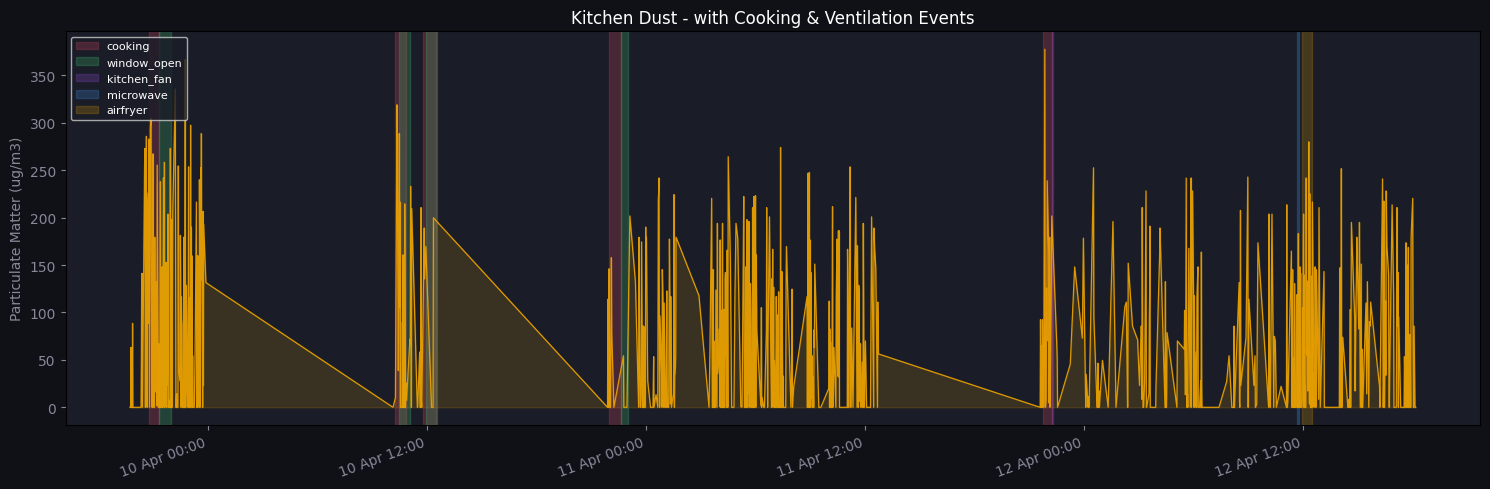

In [36]:
ev_colors = {
    'cooking': '#ff4f6e',
    'window_open': '#4ade80',
    'kitchen_fan': '#a855f7',
    'microwave': '#4a9eff',
    'airfryer': '#f0a500'
}

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(kt['ts'], kt['dust_ugm3'], color='#f0a500', linewidth=0.9, alpha=0.9)
ax.fill_between(kt['ts'], kt['dust_ugm3'], alpha=0.15, color='#f0a500')

for _, row in ev.iterrows():
    color = ev_colors.get(row['event'], 'white')
    ax.axvspan(row['start'], row['end'], alpha=0.2, color=color, label=row['event'])

handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys(),
          fontsize=8, facecolor='#1a1d27', labelcolor='white', loc='upper left')
ax.set_ylabel('Particulate Matter (ug/m3)')
ax.set_title('Kitchen Dust - with Cooking & Ventilation Events', color='white')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('images/kitchen_dust_timeline.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Cooking vs idle dust distribution

Cooking - mean: 107 ug/m3
Idle    - mean: 65 ug/m3

Note: absolute values depend on sensor calibration.
The relative difference is more meaningful than the absolute numbers.


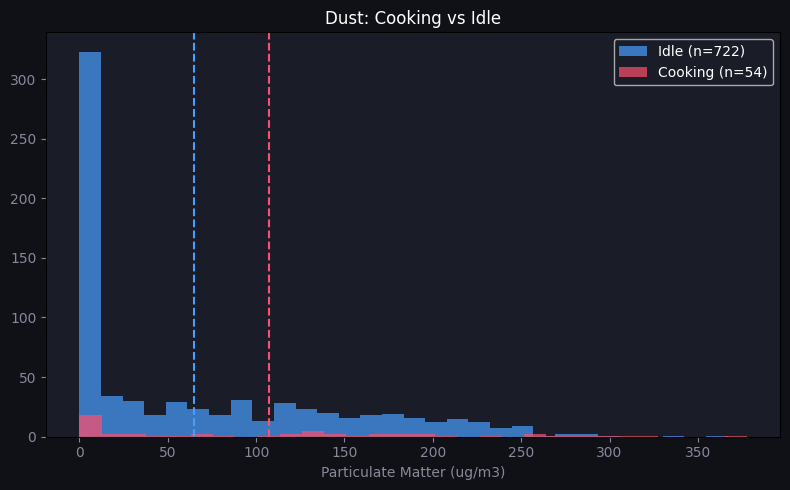

In [37]:
kt['label'] = 'idle'
for _, row in ev.iterrows():
    mask = (kt['ts'] >= row['start']) & (kt['ts'] <= row['end'])
    kt.loc[mask, 'label'] = row['event']

cooking = kt[kt['label'] == 'cooking']['dust_ugm3']
idle = kt[kt['label'] == 'idle']['dust_ugm3']

print(f"Cooking - mean: {cooking.mean():.0f} ug/m3")
print(f"Idle    - mean: {idle.mean():.0f} ug/m3")
print(f"\nNote: absolute values depend on sensor calibration.")
print(f"The relative difference is more meaningful than the absolute numbers.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(idle, bins=30, alpha=0.7, color='#4a9eff', label=f'Idle (n={len(idle)})', edgecolor='none')
ax.hist(cooking, bins=30, alpha=0.7, color='#ff4f6e', label=f'Cooking (n={len(cooking)})', edgecolor='none')
ax.axvline(idle.mean(), color='#4a9eff', linewidth=1.5, linestyle='--')
ax.axvline(cooking.mean(), color='#ff4f6e', linewidth=1.5, linestyle='--')
ax.set_xlabel('Particulate Matter (ug/m3)')
ax.set_title('Dust: Cooking vs Idle', color='white')
ax.legend(facecolor='#1a1d27', labelcolor='white')
plt.tight_layout()
plt.savefig('images/cooking_vs_idle.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Living room air quality

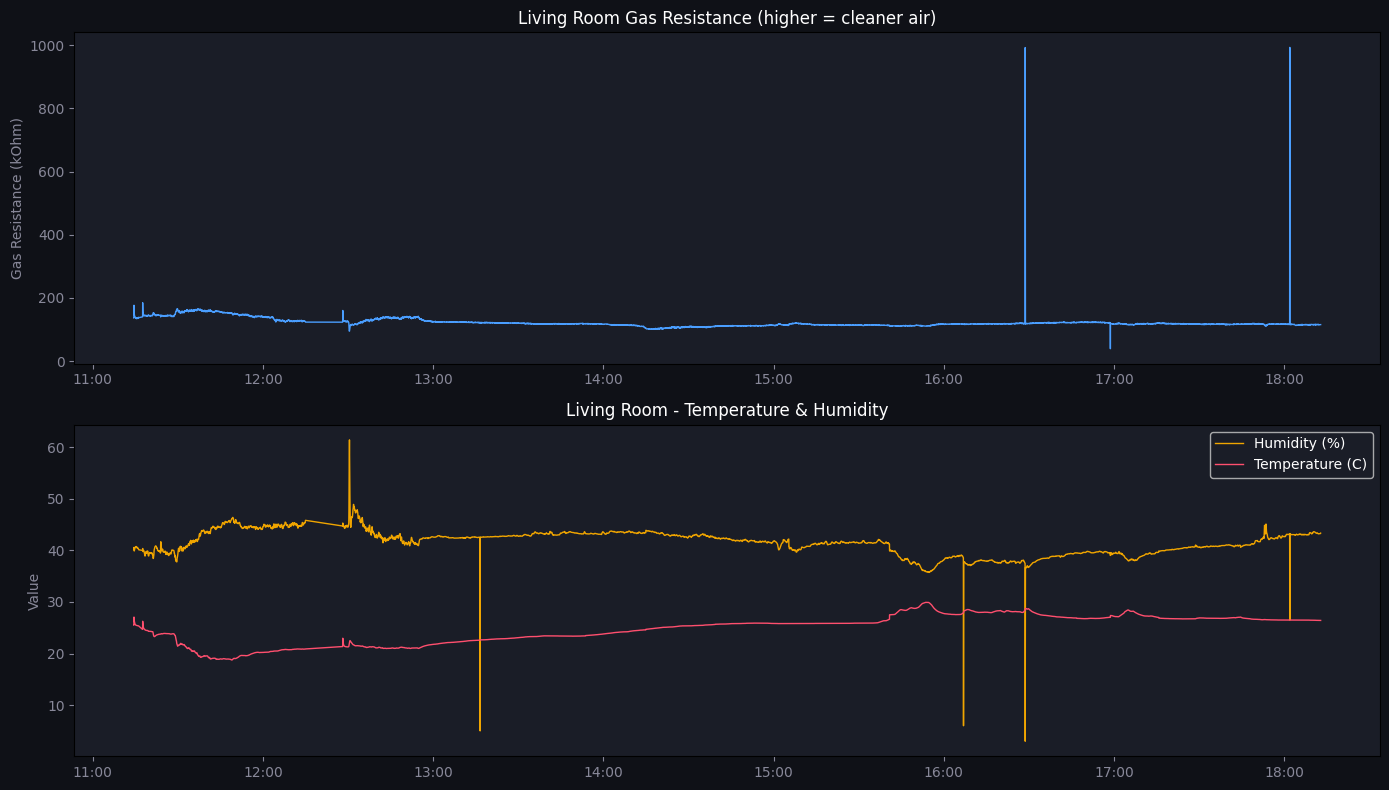

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(lr['ts'], lr['Gas'], color='#4a9eff', linewidth=1)
axes[0].set_ylabel('Gas Resistance (kOhm)')
axes[0].set_title('Living Room Gas Resistance (higher = cleaner air)', color='white')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

axes[1].plot(lr['ts'], lr['Humidity'], color='#f0a500', linewidth=1, label='Humidity (%)')
axes[1].plot(lr['ts'], lr['Temperature'], color='#ff4f6e', linewidth=1, label='Temperature (C)')
axes[1].set_ylabel('Value')
axes[1].set_title('Living Room - Temperature & Humidity', color='white')
axes[1].legend(facecolor='#1a1d27', labelcolor='white')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.savefig('images/livingroom.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 7. What I learned

**The event log was more work than the sensor setup.** Deciding what counts as a cooking event, when it starts and ends, whether to log window open separately — these labelling decisions affect the analysis. Keeping them consistent over 3 days required more discipline than expected.

**Absolute dust values need calibration caution.** The GP2Y ADC-to-µg/m³ conversion depends on LED voltage and particle size assumptions. The relative change between cooking and idle is meaningful; the absolute numbers less so.

**The living room data needs more time.** One day isn't enough to see whether kitchen activity crosses into the living room. That requires cooking events and living room data from the same timestamps.

**What I'd do next:** continue collecting to overlap kitchen and living room data, add a calibrated PM2.5 sensor, and try a simple threshold classifier for cooking detection.